# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

warnings.filterwarnings(
    'ignore',
    message='.*align should be passed as Python or NumPy boolean.*'
)

def rel_error(x, y):
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.680272118306016e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 3.865112e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738420e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


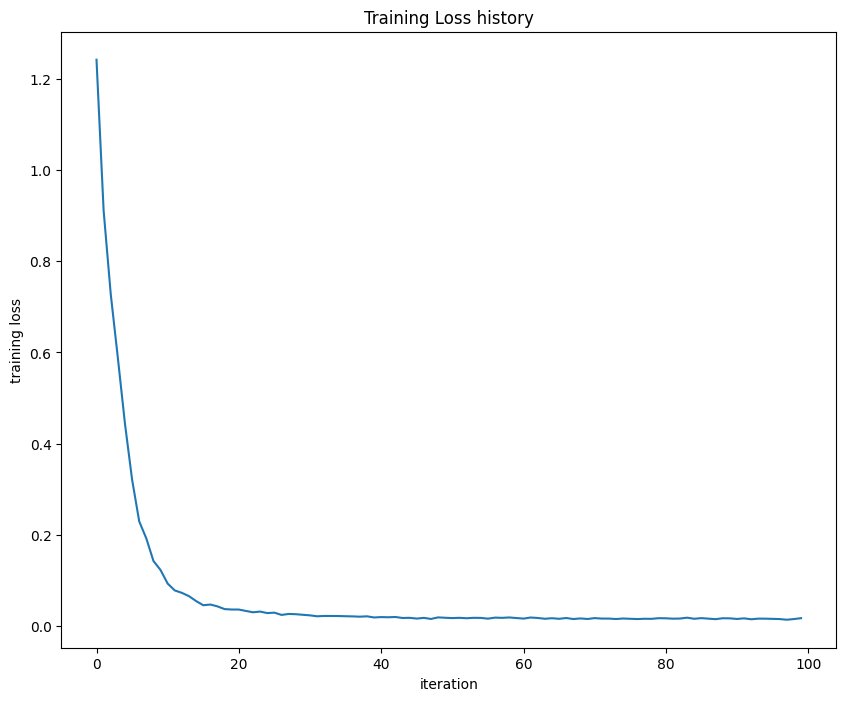

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [7]:
from scripts.data_utils import load_CIFAR10

dataset_paths = [
    'cifar-10-batches-py',
    os.path.join('scripts', 'datasets', 'cifar-10-batches-py')
]

cifar10_dir = None
for path in dataset_paths:
    if os.path.isdir(path):
        cifar10_dir = path
        break

if cifar10_dir is None:
    raise FileNotFoundError('Не найдена папка cifar-10-batches-py')

try:
    del X_train, y_train
    del X_val, y_val
    del X_test, y_test
except:
    pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

num_training = 49000
num_validation = 1000
num_test = 1000

X_val = X_train[num_training:num_training + num_validation]
y_val = y_train[num_training:num_training + num_validation]
X_train = X_train[:num_training]
y_train = y_train[:num_training]
X_test = X_test[:num_test]
y_test = y_test[:num_test]

mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

X_train = X_train.reshape(num_training, -1)
X_val = X_val.reshape(num_validation, -1)
X_test = X_test.reshape(num_test, -1)

print('Dataset path: ', cifar10_dir)
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)

Dataset path:  scripts/datasets/cifar-10-batches-py
Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)


Я использую метод `train` для обучения сети методом стохастического градиентного спуска. Параметр `X` содержит обучающие признаки, `y` содержит правильные метки классов, `X_val` и `y_val` используются для проверки качества на валидационной выборке. Параметр `learning_rate` задает скорость изменения весов, `learning_rate_decay` уменьшает скорость обучения после каждой эпохи, `reg` задает силу L2-регуляризации, `num_iters` задает количество итераций обучения, `batch_size` определяет размер случайной мини-выборки на каждой итерации, а `verbose` включает вывод промежуточного значения функции потерь.

In [8]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

default_val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', default_val_acc)

iteration 0 / 1000: loss 2.302954
iteration 100 / 1000: loss 2.302550
iteration 200 / 1000: loss 2.297648
iteration 300 / 1000: loss 2.259602
iteration 400 / 1000: loss 2.204170
iteration 500 / 1000: loss 2.118565
iteration 600 / 1000: loss 2.051535
iteration 700 / 1000: loss 1.988466
iteration 800 / 1000: loss 2.006591
iteration 900 / 1000: loss 1.951473
Validation accuracy:  0.287


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

In [9]:
input_size = X_train.shape[1]
num_classes = 10

hidden_sizes = [75, 100]
learning_rates = [7e-4, 1e-3]
regularization_strengths = [0.25, 0.5]

results = {}
best_val = -1
best_net = None
best_stats = None
best_params = None

for hidden_size in hidden_sizes:
    for learning_rate in learning_rates:
        for regularization_strength in regularization_strengths:
            net = TwoLayerNet(input_size, hidden_size, num_classes)
            current_stats = net.train(
                X_train,
                y_train,
                X_val,
                y_val,
                num_iters=1500,
                batch_size=200,
                learning_rate=learning_rate,
                learning_rate_decay=0.95,
                reg=regularization_strength,
                verbose=False
            )

            train_accuracy = (net.predict(X_train) == y_train).mean()
            val_accuracy = (net.predict(X_val) == y_val).mean()

            results[(hidden_size, learning_rate, regularization_strength)] = (train_accuracy, val_accuracy)

            if val_accuracy > best_val:
                best_val = val_accuracy
                best_net = net
                best_stats = current_stats
                best_params = (hidden_size, learning_rate, regularization_strength)

for hidden_size, learning_rate, regularization_strength in sorted(results):
    train_accuracy, val_accuracy = results[(hidden_size, learning_rate, regularization_strength)]
    print('hidden_size %d lr %e reg %e train accuracy: %f val accuracy: %f' % (
        hidden_size,
        learning_rate,
        regularization_strength,
        train_accuracy,
        val_accuracy
    ))

print('best validation accuracy: %f' % best_val)
print('best hidden_size: %d, best learning_rate: %e, best regularization_strength: %e' % best_params)

net = best_net
stats = best_stats

y_test_pred = net.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('two-layer net final test set accuracy: %f' % test_accuracy)

hidden_size 75 lr 7.000000e-04 reg 2.500000e-01 train accuracy: 0.504816 val accuracy: 0.474000
hidden_size 75 lr 7.000000e-04 reg 5.000000e-01 train accuracy: 0.497980 val accuracy: 0.485000
hidden_size 75 lr 1.000000e-03 reg 2.500000e-01 train accuracy: 0.520000 val accuracy: 0.481000
hidden_size 75 lr 1.000000e-03 reg 5.000000e-01 train accuracy: 0.510020 val accuracy: 0.485000
hidden_size 100 lr 7.000000e-04 reg 2.500000e-01 train accuracy: 0.510327 val accuracy: 0.483000
hidden_size 100 lr 7.000000e-04 reg 5.000000e-01 train accuracy: 0.497327 val accuracy: 0.483000
hidden_size 100 lr 1.000000e-03 reg 2.500000e-01 train accuracy: 0.527245 val accuracy: 0.497000
hidden_size 100 lr 1.000000e-03 reg 5.000000e-01 train accuracy: 0.514571 val accuracy: 0.492000
best validation accuracy: 0.497000
best hidden_size: 100, best learning_rate: 1.000000e-03, best regularization_strength: 2.500000e-01
two-layer net final test set accuracy: 0.508000


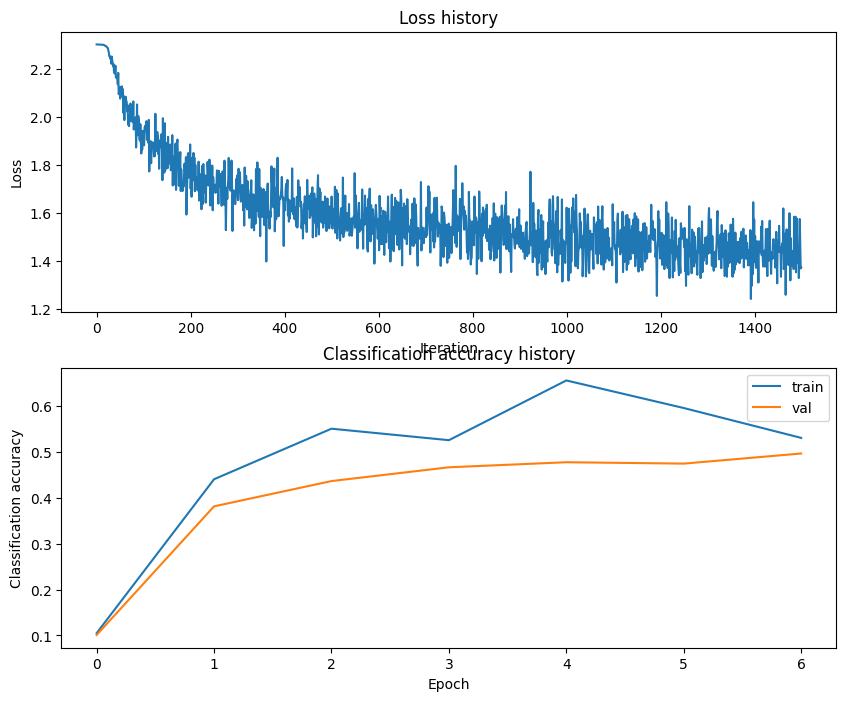

In [10]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

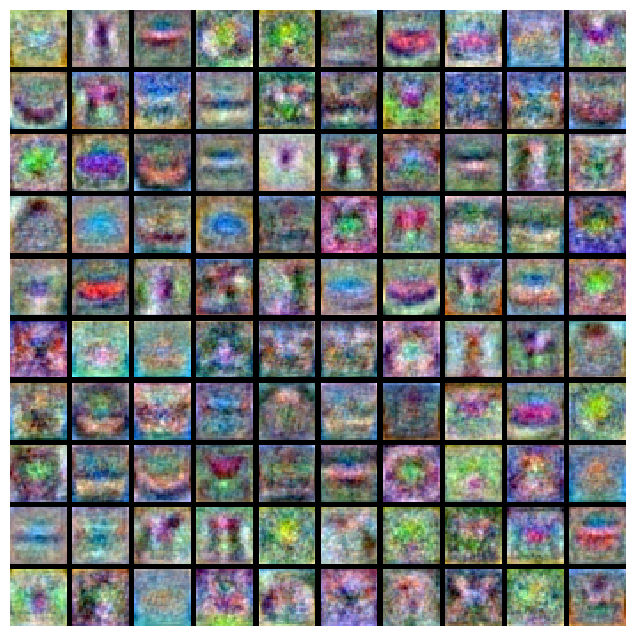

In [11]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

Сделайте выводы по результатам работы. 

In [13]:
print(
    'В этой лабораторной работе я реализовал полносвязную нейронную сеть с одним скрытым слоем для классификации изображений CIFAR-10. '
    'Сначала я проверил реализацию на модельных данных: прямой проход дал малое расхождение с эталонными значениями, функция потерь также совпала с эталоном, а численная проверка градиента показала ошибки меньше 1e-8 для W1, b1, W2 и b2. '
    'После этого я обучил сеть на CIFAR-10. При начальных параметрах accuracy на валидационной выборке составила 0.287000. '
    'Затем я выполнил подбор гиперпараметров по валидационной выборке. Лучшими параметрами стали hidden_size = %d, learning_rate = %e и regularization_strength = %e. '
    'Лучшая accuracy на валидационной выборке составила %f, а итоговая accuracy на тестовой выборке составила %f. '
    'Я сделал вывод, что качество полносвязной нейронной сети сильно зависит от скорости обучения, регуляризации и размера скрытого слоя.'
    % (best_params[0], best_params[1], best_params[2], best_val, test_accuracy)
)

В этой лабораторной работе я реализовал полносвязную нейронную сеть с одним скрытым слоем для классификации изображений CIFAR-10. Сначала я проверил реализацию на модельных данных: прямой проход дал малое расхождение с эталонными значениями, функция потерь также совпала с эталоном, а численная проверка градиента показала ошибки меньше 1e-8 для W1, b1, W2 и b2. После этого я обучил сеть на CIFAR-10. При начальных параметрах accuracy на валидационной выборке составила 0.287000. Затем я выполнил подбор гиперпараметров по валидационной выборке. Лучшими параметрами стали hidden_size = 100, learning_rate = 1.000000e-03 и regularization_strength = 2.500000e-01. Лучшая accuracy на валидационной выборке составила 0.497000, а итоговая accuracy на тестовой выборке составила 0.508000. Я сделал вывод, что качество полносвязной нейронной сети сильно зависит от скорости обучения, регуляризации и размера скрытого слоя.
